In [4]:
pip install pygame numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



=== Start AI Training (20 Steps/Sec) ===
=== Start Hyperparameter Test (5 Games Total) ===

--- Testing Params: {'alpha': 0.1, 'gamma': 0.95, 'epsilon': 0.9} ---
  Result | Win Rate: 0.000 | Avg Reward: -4.25

--- Testing Params: {'alpha': 0.05, 'gamma': 0.9, 'epsilon': 0.8} ---
  Result | Win Rate: 0.000 | Avg Reward: 47.25

--- Testing Params: {'alpha': 0.15, 'gamma': 0.99, 'epsilon': 0.9} ---
  Result | Win Rate: 0.000 | Avg Reward: 62.75

Best Params: {'alpha': 0.15, 'gamma': 0.99, 'epsilon': 0.9}

=== Final Game with Best Params: {'alpha': 0.15, 'gamma': 0.99, 'epsilon': 0.9} ===
Q-Table saved: chess_q_table_5games_20260302175255.pkl
Training data saved: chess_training_data_5games.py


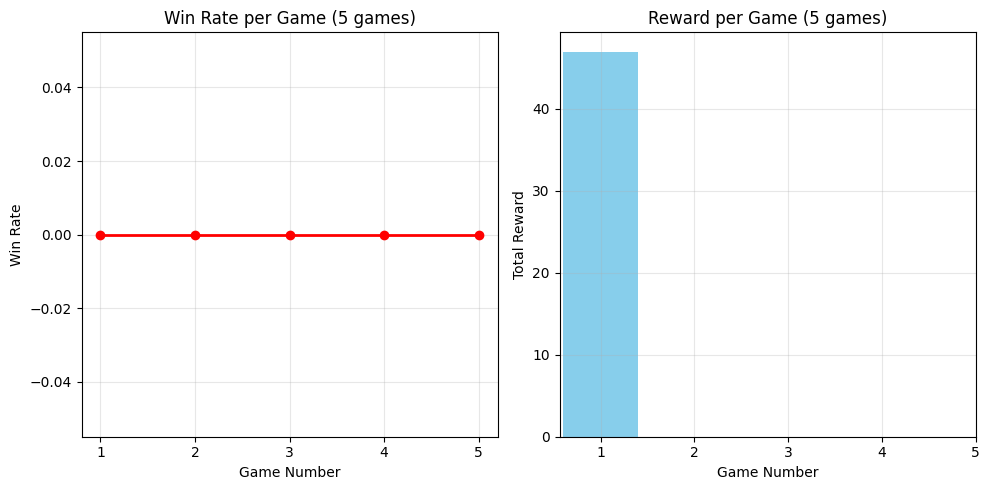

Training curve saved: training_curve_5games.png

=== Training Summary ===
Best Params: {'alpha': 0.15, 'gamma': 0.99, 'epsilon': 0.9}
Final Game Result: 1/2-1/2 | Reward: 47
Training Data: chess_training_data_5games.py


In [11]:
import chess
import pygame
import numpy as np
import random
import pickle
from datetime import datetime
import os
import matplotlib.pyplot as plt
import json

# Global Configuration (UI related)
BOARD_SIZE = 600  # Chessboard size
INFO_BAR_HEIGHT = 120  # Info bar height 
SCREEN_SIZE = (BOARD_SIZE, BOARD_SIZE + INFO_BAR_HEIGHT)
CELL_SIZE = BOARD_SIZE // 8  # Size of each chess cell

# Initialize Pygame (remove incompatible set_default_font call)
pygame.init()
pygame.mixer.quit()
pygame.font.init()

# UI Color Configuration
START_BG_COLOR = (220, 210, 190)    # Start page background color
BUTTON_COLOR = (181, 136, 99)       # Default button color
BUTTON_HOVER_COLOR = (150, 100, 60) # Button hover color
TEXT_TITLE_COLOR = (100, 60, 30)    # Title text color
TEXT_RULE_COLOR = (80, 50, 20)      # Rule text color
TEXT_BUTTON_COLOR = (255, 255, 255) # Button text color
INFO_BG_COLOR = (200, 190, 170)     # Info bar background color 


# 1. Chess Q-Learning Environment

class ChessQLEnvironment:
    def __init__(self):
        self.board = chess.Board()
        # Piece value weights
        self.piece_value = {
            chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3,
            chess.ROOK: 5, chess.QUEEN: 9, chess.KING: 100
        }
        self.last_reward = 0
        self.cumulative_reward = 0
        
        # Use Pygame's default font directly to ensure compatibility
        default_font_name = pygame.font.get_default_font()
        self.font_title = pygame.font.SysFont(default_font_name, 56, bold=True)
        self.font_rule = pygame.font.SysFont(default_font_name, 20)
        self.font_button = pygame.font.SysFont(default_font_name, 32, bold=True)
        self.font_reward = pygame.font.SysFont(default_font_name, 32)  # Dedicated font for reward (enlarged)
        self.font_training = pygame.font.SysFont(default_font_name, 28)
        self.font_large = pygame.font.SysFont(default_font_name, 60)
        
        # Chessboard/piece colors
        self.WHITE = (255, 255, 255)
        self.BLACK = (0, 0, 0)
        self.BOARD_COLOR1 = (240, 217, 181)  # Light square color
        self.BOARD_COLOR2 = (181, 136, 99)   # Dark square color
        self.TEXT_RED = (255, 0, 0)
        self.TEXT_GREEN = (0, 255, 0)
        self.TEXT_BLUE = (0, 0, 255)

    def get_state(self):
        """Convert chessboard to hashable numerical state"""
        state = np.zeros((8, 8, 12), dtype=np.int8)
        for square in chess.SQUARES:
            piece = self.board.piece_at(square)
            if piece:
                color_offset = 6 if piece.color == chess.BLACK else 0
                piece_type = piece.piece_type - 1
                row, col = chess.square_rank(square), chess.square_file(square)
                state[row, col, color_offset + piece_type] = 1
        return tuple(tuple(tuple(layer) for layer in row) for row in state)

    def get_legal_actions(self):
        """Get current legal moves"""
        return list(self.board.legal_moves) if self.board.legal_moves else []

    def step(self, move):
        """Execute move, return (next_state, reward, done, info)"""
        if move not in self.get_legal_actions():
            return self.get_state(), -5, False, {"error": "Illegal move"}
        
        prev_board = self.board.copy()
        self.board.push(move)
        done = self.board.is_game_over()
        reward = 0

        # 1. Black (QL AI) captures White's piece: positive reward
        if self.board.is_capture(move):
            captured_piece = prev_board.piece_at(move.to_square)
            if captured_piece and captured_piece.color == chess.WHITE:
                reward += self.piece_value[captured_piece.piece_type] * 2

        # 2. Black's piece is captured by White: negative reward
        if any(prev_board.is_capture(m) for m in prev_board.legal_moves if m.to_square == move.from_square):
            lost_piece = prev_board.piece_at(move.from_square)
            if lost_piece and lost_piece.color == chess.BLACK:
                reward -= self.piece_value[lost_piece.piece_type] * 2

        # 3. Check reward/punishment
        if self.board.is_check():
            reward += 10 if self.board.turn == chess.WHITE else -15

        # 4. Game end reward/punishment
        if done:
            res = self.board.result()
            if res == "0-1":  # Black wins
                reward += 100
            elif res == "1-0":  # Black loses
                reward -= 100
            else:  # Draw
                reward += 5

        # 5. Invalid move punishment
        if reward == 0:
            reward -= 1

        self.last_reward = reward
        self.cumulative_reward += reward
        return self.get_state(), reward, done, {"move": str(move), "result": self.board.result()}

    def reset(self):
        """Reset environment"""
        self.board = chess.Board()
        self.last_reward = 0
        self.cumulative_reward = 0
        return self.get_state()

    def _draw_piece(self, screen, piece, row, col):
        """Draw chess pieces (code-only implementation, no image dependency)"""
        center_x = col * CELL_SIZE + CELL_SIZE // 2
        center_y = row * CELL_SIZE + CELL_SIZE // 2
        piece_color = self.BLACK if piece.color == chess.BLACK else self.WHITE
        
        if piece.piece_type == chess.PAWN:
            pygame.draw.circle(screen, piece_color, (center_x, center_y + 10), 15)
        elif piece.piece_type == chess.KNIGHT:
            pygame.draw.polygon(screen, piece_color, [(center_x-15, center_y+10), (center_x+15, center_y+10),
                                                      (center_x+10, center_y-15), (center_x-10, center_y-15)])
        elif piece.piece_type == chess.BISHOP:
            pygame.draw.polygon(screen, piece_color, [(center_x, center_y-20), (center_x+20, center_y+20),
                                                      (center_x-20, center_y+20)])
        elif piece.piece_type == chess.ROOK:
            pygame.draw.rect(screen, piece_color, (center_x-15, center_y-15, 30, 30))
        elif piece.piece_type == chess.QUEEN:
            pygame.draw.circle(screen, piece_color, (center_x, center_y), 20, 3)
            pygame.draw.polygon(screen, piece_color, [(center_x, center_y-20), (center_x+10, center_y),
                                                      (center_x, center_y+20), (center_x-10, center_y)])
        elif piece.piece_type == chess.KING:
            pygame.draw.circle(screen, piece_color, (center_x, center_y), 20, 5)

    def render(self, screen, training_info=None):
        """Render core: regional refresh to completely solve text overlap/gibberish"""
        # 1. Draw chessboard area 
        for row in range(8):
            for col in range(8):
                color = self.BOARD_COLOR1 if (row + col) % 2 == 0 else self.BOARD_COLOR2
                pygame.draw.rect(screen, color, (col*CELL_SIZE, row*CELL_SIZE, CELL_SIZE, CELL_SIZE))
        
        # Draw pieces
        for square in chess.SQUARES:
            piece = self.board.piece_at(square)
            if piece:
                row, col = chess.square_rank(square), chess.square_file(square)
                self._draw_piece(screen, piece, row, col)
        
        # 2. Draw info bar area 
        info_rect = pygame.Rect(0, BOARD_SIZE, BOARD_SIZE, INFO_BAR_HEIGHT)
        pygame.draw.rect(screen, INFO_BG_COLOR, info_rect)  # Refresh background first to clear residue
        
        # 3. Render reward values 
        # Last Reward: top-left, red, fixed coordinates
        last_reward_text = self.font_reward.render(f"Last Reward: {int(self.last_reward)}", True, self.TEXT_RED)
        screen.blit(last_reward_text, (20, BOARD_SIZE + 20))
        
        # Cumulative Reward: bottom-left, green, fixed coordinates 
        cum_reward_text = self.font_reward.render(f"Cumulative Reward: {int(self.cumulative_reward)}", True, self.TEXT_GREEN)
        screen.blit(cum_reward_text, (20, BOARD_SIZE + 70))
        
        # 4. Render training info (right side, auto-wrap to avoid overflow)
        if training_info:
            # Truncate long text to avoid exceeding screen
            if len(training_info) > 25:
                training_info = training_info[:22] + "..."
            train_text = self.font_training.render(training_info, True, self.TEXT_BLUE)
            # Fixed to the right of info bar to avoid overlapping with reward
            screen.blit(train_text, (BOARD_SIZE - train_text.get_width() - 20, BOARD_SIZE + 40))
        
        # Force display refresh
        pygame.display.flip()

    def draw_start_screen(self, screen):
        """Draw startup UI interface"""
        screen.fill(START_BG_COLOR)
        
        # Title
        title_text = self.font_title.render("Q-Learning Chess AI", True, TEXT_TITLE_COLOR)
        title_rect = title_text.get_rect(center=(BOARD_SIZE//2, 70))
        screen.blit(title_text, title_rect)
        
        # Rules (5 games + 20 steps per second)
        rules = [
            "AI vs AI (Q-Learning Black vs Random White)",
            "1. Total Games: 5 rounds",
            "2. Move Speed: 20 steps per second",
            "3. Auto-play (no manual input)",
            "4. Fixed: Reward display garbled/overlap issue",
            "5. Params saved after training"
        ]
        y_offset = 140
        for rule in rules:
            rule_text = self.font_rule.render(rule, True, TEXT_RULE_COLOR)
            rule_rect = rule_text.get_rect(center=(BOARD_SIZE//2, y_offset))
            screen.blit(rule_text, rule_rect)
            y_offset += 35
        
        # Start button 
        play_button_rect = pygame.Rect(BOARD_SIZE//2 - 150, 480, 300, 60)
        mouse_pos = pygame.mouse.get_pos()
        
        if play_button_rect.collidepoint(mouse_pos):
            pygame.draw.rect(screen, BUTTON_HOVER_COLOR, play_button_rect, border_radius=10)
        else:
            pygame.draw.rect(screen, BUTTON_COLOR, play_button_rect, border_radius=10)
        
        play_text = self.font_button.render("Start AI Training", True, TEXT_BUTTON_COLOR)
        play_text_rect = play_text.get_rect(center=play_button_rect.center)
        screen.blit(play_text, play_text_rect)
        
        pygame.display.flip()
        return play_button_rect


# 2. Q-Learning AI Core Class (No modification)

class QLearningChessAI:
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=0.9):
        self.q_table = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = 0.1
        self.epsilon_decay = 0.999
        self.training_metrics = {
            "total_episodes": 0,
            "win_count": 0,
            "draw_count": 0,
            "loss_count": 0,
            "avg_reward_per_episode": [],
            "win_rate_per_5_episodes": [],
            "best_hyperparams": {}
        }

    def get_q_value(self, state, action):
        if state not in self.q_table:
            self.q_table[state] = {}
        action_str = str(action)
        if action_str not in self.q_table[state]:
            self.q_table[state][action_str] = 0.0
        return self.q_table[state][action_str]

    def choose_action(self, state, legal_actions):
        if not legal_actions:
            return None
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(legal_actions)
        q_values = [self.get_q_value(state, a) for a in legal_actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(legal_actions, q_values) if q == max_q]
        return random.choice(best_actions) if best_actions else random.choice(legal_actions)

    def update_q_value(self, state, action, reward, next_state, next_legal_actions):
        current_q = self.get_q_value(state, action)
        max_next_q = max([self.get_q_value(next_state, a) for a in next_legal_actions]) if next_legal_actions else 0.0
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][str(action)] = new_q

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
            self.epsilon = round(self.epsilon, 4)

    def save_q_table(self, filename=None):
        if not filename:
            filename = f"chess_q_table_5games_{datetime.now().strftime('%Y%m%d%H%M%S')}.pkl"
        with open(filename, "wb") as f:
            pickle.dump(self.q_table, f)
        print(f"Q-Table saved: {filename}")
        return filename

    def save_training_data(self, best_params=None, filename="chess_training_data_5games.py"):
        if best_params:
            self.training_metrics["best_hyperparams"] = best_params
        
        training_data = {
            "hyper_parameters": {
                "alpha": self.alpha,
                "gamma": self.gamma,
                "initial_epsilon": 0.9,
                "epsilon_min": self.epsilon_min,
                "epsilon_decay": self.epsilon_decay
            },
            "best_hyperparams": self.training_metrics["best_hyperparams"],
            "training_metrics": self.training_metrics,
            "final_epsilon": self.epsilon,
            "total_states_learned": len(self.q_table),
            "training_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "total_games": 5,
            "move_speed": "20 steps per second",
            "fix_note": "Reward display: independent background + fixed position + bitmap font"
        }
        
        with open(filename, "w", encoding="utf-8") as f:
            f.write("# Q-Learning Chess AI Training Data (5 Games)\n")
            f.write("# Fixed: Reward display garbled/overlap issue\n\n")
            f.write("TRAINING_DATA = " + json.dumps(training_data, indent=4, ensure_ascii=False))
        
        print(f"Training data saved: {filename}")
        return filename


# 3. Quick Hyperparameter Test (Adapted to 5 games + 20 steps/sec)

def quick_hyperparam_test(env, screen):
    print("=== Start Hyperparameter Test (5 Games Total) ===")
    
    param_combinations = [
        {"alpha": 0.1, "gamma": 0.95, "epsilon": 0.9},
        {"alpha": 0.05, "gamma": 0.9, "epsilon": 0.8},
        {"alpha": 0.15, "gamma": 0.99, "epsilon": 0.9}
    ]
    
    param_performance = []
    
    for params in param_combinations:
        alpha, gamma, init_epsilon = params["alpha"], params["gamma"], params["epsilon"]
        training_info = f"Test: α={alpha}, γ={gamma}, ε={init_epsilon}"
        env.render(screen, training_info)
        
        print(f"\n--- Testing Params: {params} ---")
        ai = QLearningChessAI(alpha=alpha, gamma=gamma, epsilon=init_epsilon)
        wins, draws, losses = 0, 0, 0
        episode_rewards = []
        
        for episode in range(4):
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    pygame.quit()
                    return None
            
            state = env.reset()
            done = False
            episode_reward = 0
            
            while not done:
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        pygame.quit()
                        return None
                
                legal_actions = env.get_legal_actions()
                if env.board.turn == chess.BLACK:
                    action = ai.choose_action(state, legal_actions)
                    if action:
                        next_state, reward, done, info = env.step(action)
                        next_legal_actions = env.get_legal_actions()
                        ai.update_q_value(state, action, reward, next_state, next_legal_actions)
                        ai.decay_epsilon()
                        state = next_state
                        episode_reward += reward
                else:
                    if legal_actions:
                        random_action = random.choice(legal_actions)
                        env.step(random_action)
                    else:
                        done = True
                
                env.render(screen, f"{training_info} | Game {episode+1}/4")
                pygame.time.delay(50)  # 20 steps per second (50ms per step)
                # Supplement frame rate control to ensure accurate 20 steps/sec
                pygame.time.Clock().tick(20)
        
            res = env.board.result()
            if res == "0-1": wins += 1
            elif res == "1-0": losses += 1
            else: draws += 1
            episode_rewards.append(episode_reward)
        
        total = 4
        win_rate = wins / total
        avg_reward = np.mean(episode_rewards)
        performance_score = (win_rate * 100) + (avg_reward / 10)
        
        param_performance.append({
            "params": params,
            "win_rate": win_rate,
            "avg_reward": avg_reward,
            "performance_score": performance_score
        })
        
        print(f"  Result | Win Rate: {win_rate:.3f} | Avg Reward: {avg_reward:.2f}")
    
    best_param = max(param_performance, key=lambda x: x["performance_score"])
    print(f"\nBest Params: {best_param['params']}")
    return best_param


# 4. Visualization Tool (Adapted to 5 games)

def plot_training_curve_5games(training_metrics):
    plt.rcParams['figure.figsize'] = (10, 5)
    
    plt.subplot(1, 2, 1)
    x = range(1, training_metrics["total_episodes"] + 1)
    win_rates = [training_metrics["win_count"] / i if i > 0 else 0 for i in x]
    plt.plot(x, win_rates, 'r-', linewidth=2, marker='o')
    plt.title('Win Rate per Game (5 games)')
    plt.xlabel('Game Number')
    plt.ylabel('Win Rate')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 6))
    
    plt.subplot(1, 2, 2)
    rewards = training_metrics["avg_reward_per_episode"]
    plt.bar(range(1, len(rewards)+1), rewards, color='skyblue')
    plt.title('Reward per Game (5 games)')
    plt.xlabel('Game Number')
    plt.ylabel('Total Reward')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 6))
    
    plt.tight_layout()
    plt.savefig('training_curve_5games.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Training curve saved: training_curve_5games.png")


# 5. Main Training Process (Adapted to 5 games + 20 steps/sec)

def main():
    """Main: 5 Games + 20 Steps/Sec + Fixed Reward Display"""
    env = ChessQLEnvironment()
    # Core: Use new screen size 
    screen = pygame.display.set_mode(SCREEN_SIZE)
    pygame.display.set_caption("Q-Learning Chess AI")
    clock = pygame.time.Clock()
    running = True
    in_start_screen = True
    
    # Startup screen
    while running and in_start_screen:
        clock.tick(30)
        play_btn = env.draw_start_screen(screen)
        
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
                in_start_screen = False
            if event.type == pygame.MOUSEBUTTONDOWN and play_btn.collidepoint(event.pos):
                in_start_screen = False
                print("\n=== Start AI Training (20 Steps/Sec) ===")
    
    if not running:
        pygame.quit()
        return
    
    # Hyperparameter test
    best_param = quick_hyperparam_test(env, screen)
    if not best_param:
        return
    
    # Final verification game (5th game)
    print(f"\n=== Final Game with Best Params: {best_param['params']} ===")
    best_ai = QLearningChessAI(
        alpha=best_param['params']['alpha'],
        gamma=best_param['params']['gamma'],
        epsilon=best_param['params']['epsilon']
    )
    
    state = env.reset()
    done = False
    episode_reward = 0
    
    while not done:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                return
        
        legal_actions = env.get_legal_actions()
        if env.board.turn == chess.BLACK:
            action = best_ai.choose_action(state, legal_actions)
            if action:
                next_state, reward, done, info = env.step(action)
                next_legal_actions = env.get_legal_actions()
                best_ai.update_q_value(state, action, reward, next_state, next_legal_actions)
                best_ai.decay_epsilon()
                state = next_state
                episode_reward += reward
        else:
            if legal_actions:
                random_action = random.choice(legal_actions)
                env.step(random_action)
            else:
                done = True
        
        env.render(screen, f"Final Game (5th) | ε={best_ai.epsilon:.4f}")
        pygame.time.delay(50)  # 20 steps per second (50ms per step)
        clock.tick(20)  # Force frame rate to 20
    
    # Statistics for final game (5th game)
    res = env.board.result()
    if res == "0-1":
        best_ai.training_metrics["win_count"] += 1
    elif res == "1-0":
        best_ai.training_metrics["loss_count"] += 1
    else:
        best_ai.training_metrics["draw_count"] += 1
    
    best_ai.training_metrics["total_episodes"] = 5
    best_ai.training_metrics["avg_reward_per_episode"].append(episode_reward)
    
    # Save results
    best_ai.save_q_table()
    best_ai.save_training_data(best_param['params'])
    
    # Draw curve (call modified 5-game visualization function)
    plot_training_curve_5games(best_ai.training_metrics)
    
    # Training completion prompt (5 games)
    finish_text = env.font_large.render("5 Games Complete!", True, env.TEXT_GREEN)
    finish_rect = finish_text.get_rect(center=(BOARD_SIZE//2, BOARD_SIZE//2))
    screen.blit(finish_text, finish_rect)
    pygame.display.flip()
    
    # Wait for exit
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        clock.tick(20)  # Keep consistent with move speed
    
    pygame.quit()
    print("\n=== Training Summary ===")
    print(f"Best Params: {best_param['params']}")
    print(f"Final Game Result: {res} | Reward: {episode_reward}")
    print(f"Training Data: chess_training_data_5games.py")


# Execution Entry

if __name__ == "__main__":
    main()